Exploratory Data Analysis for the merged CRMLS Listing and Sold datasets (202401-202605). Reads the outputs of Dataset Aggregation.ipynb and runs:
 
  1. Confirm dataset time range
  2. Validate merged Sold and Listing datasets (structure)
  3. Review unique PropertyType values
  4. Identify high-missing-value columns (+ chart)
  5. Separate market analysis fields from metadata fields (+ chart)
  6. Review numerical variable distributions (+ charts)
  7. Answer suggested EDA questions (+ charts)
 

# Install Package

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Config

In [17]:
DATA_DIR = r"D:\Meng\document\AU\Career\2026 Intern\IDX\2. Data Analyst summer 2026\csv"
START_MONTH = 202401
END_MONTH = 202605
 
CHART_DIR = os.path.join(DATA_DIR, "eda_charts")
os.makedirs(CHART_DIR, exist_ok=True)
 
LISTING_ORIGIN_PATH = os.path.join(DATA_DIR, f"Listing_Origin_{START_MONTH}_{END_MONTH}.csv")
LISTING_RESIDENTIAL_PATH = os.path.join(DATA_DIR, f"Listing_Residential_{START_MONTH}_{END_MONTH}.csv")
SOLD_ORIGIN_PATH = os.path.join(DATA_DIR, f"Sold_Origin_{START_MONTH}_{END_MONTH}.csv")
SOLD_RESIDENTIAL_PATH = os.path.join(DATA_DIR, f"Sold_Residential_{START_MONTH}_{END_MONTH}.csv")

In [3]:
NUMERIC_FIELDS = [
    "ClosePrice", "ListPrice", "LivingArea", "LotSizeAcres",
    "BedroomsTotal", "BathroomsTotalInteger", "DaysOnMarket", "YearBuilt",
]

# Column classification for market analysis
MARKET_FIELDS = {
    "OriginalListPrice", "ListPrice", "ClosePrice",
    "LivingArea", "AboveGradeFinishedArea", "BelowGradeFinishedArea", "BuildingAreaTotal",
    "LotSizeAcres", "LotSizeArea", "LotSizeSquareFeet", "LotSizeDimensions",
    "BedroomsTotal", "BathroomsTotalInteger", "MainLevelBedrooms",
    "YearBuilt", "Stories", "Levels", "DaysOnMarket",
    "PropertyType", "PropertySubType", "BusinessType", "MlsStatus",
    "City", "CountyOrParish", "StateOrProvince", "PostalCode", "MLSAreaMajor",
    "SubdivisionName", "Latitude", "Longitude", "StreetNumberNumeric", "UnparsedAddress",
    "GarageSpaces", "ParkingTotal", "CoveredSpaces", "AttachedGarageYN",
    "FireplacesTotal", "FireplaceYN", "AssociationFee", "AssociationFeeFrequency",
    "TaxAnnualAmount", "TaxYear", "NewConstructionYN", "BuilderName",
    "ElementarySchool", "MiddleOrJuniorSchool", "HighSchool",
    "ElementarySchoolDistrict", "MiddleOrJuniorSchoolDistrict", "HighSchoolDistrict",
    "ListingContractDate", "ContractStatusChangeDate", "PurchaseContractDate", "CloseDate",
    "BuyerAgencyCompensation", "BuyerAgencyCompensationType",
}

METADATA_FIELDS = {
    "ListingKey", "ListingKeyNumeric", "ListingId",
    "ListAgentEmail", "ListAgentFirstName", "ListAgentLastName", "ListAgentFullName",
    "ListAgentAOR", "CoListAgentFirstName", "CoListAgentLastName", "CoListOfficeName",
    "BuyerAgentMlsId", "BuyerAgentFirstName", "BuyerAgentLastName", "BuyerAgentAOR",
    "CoBuyerAgentFirstName", "ListOfficeName", "BuyerOfficeName", "BuyerOfficeAOR",
    "SourceMonth", "lonfilled", "latfilled",
    "OriginatingSystemName", "OriginatingSystemSubName",
}

In [7]:
# Charts are saved as PNGs to DATA_DIR/eda_charts and also displayed 
# via plt.show() (works whether you run this as a script or in Jupyter/Colab)
def save_and_show(fig, filename):
    path = os.path.join(CHART_DIR, filename)
    fig.savefig(path, bbox_inches="tight", dpi=120)
    print(f"  Chart saved: {path}")
    plt.show()
    plt.close(fig)

# Task 1: Read Files to comfirm dataset time range

In [19]:
print("Loading merged datasets...")
Listing_Origin = pd.read_csv(LISTING_ORIGIN_PATH, low_memory=False)
Listing_Residential = pd.read_csv(LISTING_RESIDENTIAL_PATH, low_memory=False)
Sold_Origin = pd.read_csv(SOLD_ORIGIN_PATH, low_memory=False)
Sold_Residential = pd.read_csv(SOLD_RESIDENTIAL_PATH, low_memory=False)
print(f"Listing (Without Filter): {Listing_Origin.shape[0]} rows, {Listing_Origin.shape[1]} columns")
print(f"Listing (Residential Type): {Listing_Residential.shape[0]} rows, {Listing_Residential.shape[1]} columns")
print(f"Sold (Without Filter): {Sold_Origin.shape[0]} rows, {Sold_Origin.shape[1]} columns")
print(f"Sold (Residential Type): {Sold_Residential.shape[0]} rows, {Sold_Residential.shape[1]} columns")

Loading merged datasets...
Listing (Without Filter): 929709 rows, 84 columns
Listing (Residential Type): 591568 rows, 84 columns
Sold (Without Filter): 639920 rows, 84 columns
Sold (Residential Type): 430447 rows, 84 columns


# Task 2: Validate Merged Sold and Listing Datasets

In [22]:
def validate_structure(df, label):
    print(f"\n--- [{label}] Structure ---")
    print(f"  Rows: {df.shape[0]}, Columns: {df.shape[1]}")
    print("  Dtype breakdown:")
    print(df.dtypes.value_counts().to_string())
    print(f"  Column names ({df.shape[1]}):")
    print(f"  {list(df.columns)}")
 
 
validate_structure(Listing_Residential, "Listing (Residential Type)")
validate_structure(Sold_Residential, "Sold (Residential Type)")


--- [Listing (Residential Type)] Structure ---
  Rows: 591568, Columns: 84
  Dtype breakdown:
object     47
float64    33
int64       4
  Column names (84):
  ['OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate', 'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude', 'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea', 'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName', 'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency', 'AboveGradeFinishedArea', 'ListingKeyNumeric', 'MLSAreaMajor', 'TaxAnnualAmount', 'CountyOrParish', 'PropertyType.1', 'MlsStatus', 'ElementarySchool', 'ListAgentFirstName.1', 'AttachedGarageYN', 'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres', 'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'DaysOnMarket.1', 'BuyerAgencyCompensationType', 'StreetNumberNumer

# Task 3: Review Unique PropertyType Values

In [23]:
def review_property_types(df, label):
    print(f"\n--- [{label}] PropertyType Values ---")
    counts = df["PropertyType"].value_counts(dropna=False)
    pct = (counts / len(df) * 100).round(2)
    table = pd.DataFrame({"Count": counts, "Percent": pct})
    print(table.to_string())
    return table
 
 
listing_ptype = review_property_types(Listing_Residential, "Listing (Residential Type)")
sold_ptype = review_property_types(Sold_Residential, "Sold (Residential Type)")


--- [Listing (Residential Type)] PropertyType Values ---
               Count  Percent
PropertyType                 
Residential   591568    100.0

--- [Sold (Residential Type)] PropertyType Values ---
               Count  Percent
PropertyType                 
Residential   430447    100.0


# Task 4: Identify High-Missing-Value Columns


--- [Listing (Residential Type)] Missing Value Analysis ---
  Columns with >90% missing (13):
                              MissingCount  MissingPct
TaxYear                             591568      100.00
TaxAnnualAmount                     591568      100.00
AboveGradeFinishedArea              591568      100.00
FireplacesTotal                     591568      100.00
ElementarySchoolDistrict            591568      100.00
BusinessType                        591568      100.00
CoveredSpaces                       591568      100.00
MiddleOrJuniorSchoolDistrict        591568      100.00
BelowGradeFinishedArea              588195       99.43
CoBuyerAgentFirstName               576970       97.53
BuilderName                         564213       95.38
LotSizeDimensions                   560578       94.76
BuildingAreaTotal                   538780       91.08
  Chart saved: D:\Meng\document\AU\Career\2026 Intern\IDX\2. Data Analyst summer 2026\csv\eda_charts\listing (residential type)_missing

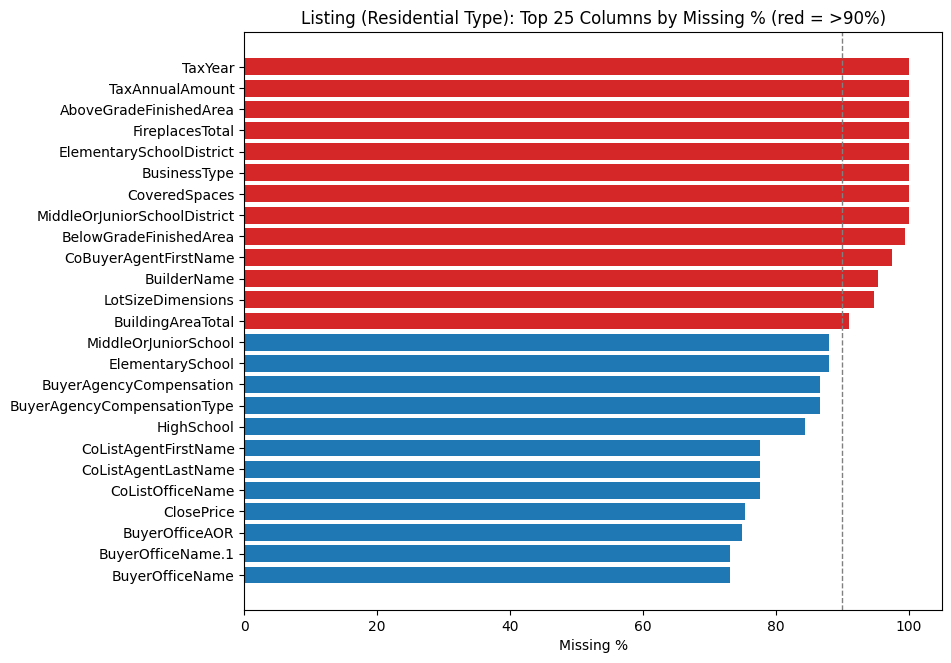


--- [Sold (Residential Type)] Missing Value Analysis ---
  Columns with >90% missing (15):
                              MissingCount  MissingPct
TaxYear                             430447      100.00
FireplacesTotal                     430447      100.00
TaxAnnualAmount                     430447      100.00
AboveGradeFinishedArea              430447      100.00
ElementarySchoolDistrict            430447      100.00
BusinessType                        430447      100.00
CoveredSpaces                       430447      100.00
MiddleOrJuniorSchoolDistrict        430447      100.00
WaterfrontYN                        430176       99.94
BelowGradeFinishedArea              427921       99.41
BasementYN                          422009       98.04
LotSizeDimensions                   409548       95.14
BuilderName                         409376       95.10
BuildingAreaTotal                   400275       92.99
CoBuyerAgentFirstName               391170       90.88
  Chart saved: D:\Meng\docum

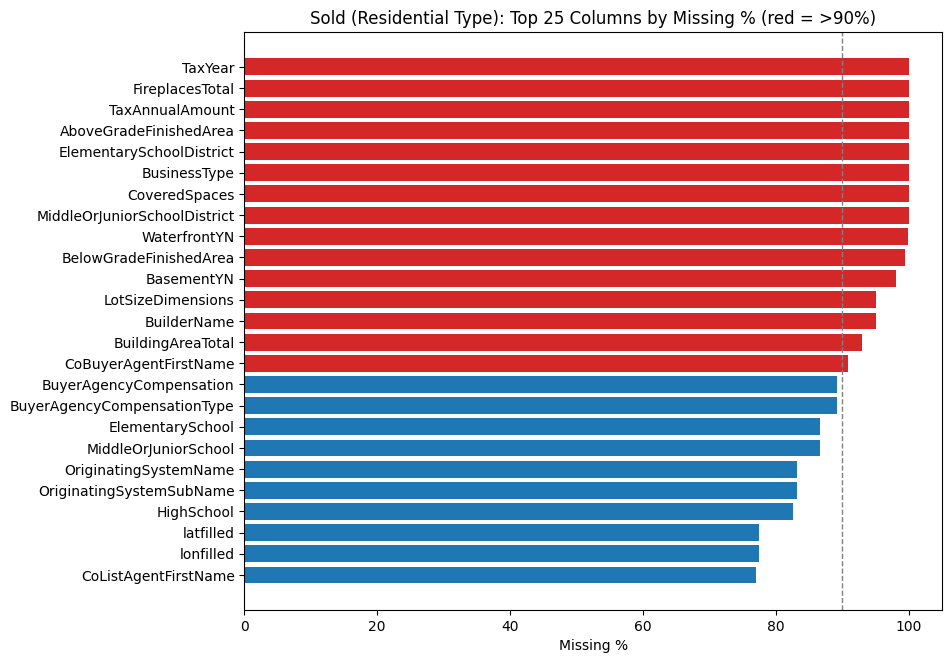

In [24]:
def missing_value_analysis(df, label):
    print(f"\n--- [{label}] Missing Value Analysis ---")
    miss_count = df.isna().sum()
    miss_pct = (miss_count / len(df) * 100).round(2)
    summary = pd.DataFrame({"MissingCount": miss_count, "MissingPct": miss_pct})
    summary = summary.sort_values("MissingPct", ascending=False)
 
    high_missing = summary[summary["MissingPct"] > 90]
    print(f"  Columns with >90% missing ({len(high_missing)}):")
    print(high_missing.to_string())
 
    top = summary.head(25)
    fig, ax = plt.subplots(figsize=(9, max(4, len(top) * 0.3)))
    colors = ["#d62728" if v > 90 else "#1f77b4" for v in top["MissingPct"]]
    ax.barh(top.index[::-1], top["MissingPct"][::-1], color=colors[::-1])
    ax.axvline(90, color="gray", linestyle="--", linewidth=1)
    ax.set_xlabel("Missing %")
    ax.set_title(f"{label}: Top 25 Columns by Missing % (red = >90%)")
    save_and_show(fig, f"{label.lower()}_missing_values.png")
 
    return summary
 
 
listing_missing = missing_value_analysis(Listing_Residential, "Listing (Residential Type)")
sold_missing = missing_value_analysis(Sold_Residential, "Sold (Residential Type)")
 

# Task 5: Separate Market Analysis Fields from Metadata Fields


--- [Listing (Residential Type)] Field Classification ---
  Market analysis fields: 56
  Metadata fields: 17
  Uncategorized (review and classify manually): ['PropertyType.1', 'ListAgentFirstName.1', 'DaysOnMarket.1', 'LivingArea.1', 'Longitude.1', 'Latitude.1', 'ListPrice.1', 'ListAgentLastName.1', 'CloseDate.1', 'BuyerOfficeName.1', 'UnparsedAddress.1']
  Chart saved: D:\Meng\document\AU\Career\2026 Intern\IDX\2. Data Analyst summer 2026\csv\eda_charts\listing (residential type)_field_classification.png


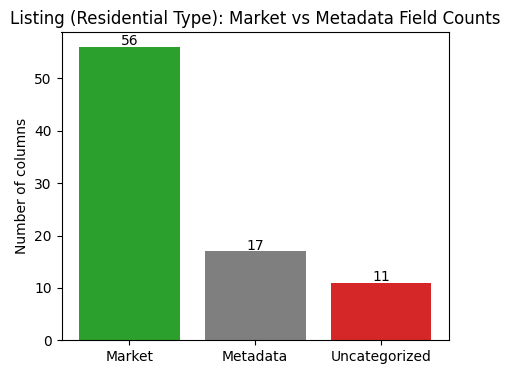


--- [Sold (Residential Type)] Field Classification ---
  Market analysis fields: 56
  Metadata fields: 23
  Uncategorized (review and classify manually): ['Flooring', 'ViewYN', 'WaterfrontYN', 'BasementYN', 'PoolPrivateYN']
  Chart saved: D:\Meng\document\AU\Career\2026 Intern\IDX\2. Data Analyst summer 2026\csv\eda_charts\sold (residential type)_field_classification.png


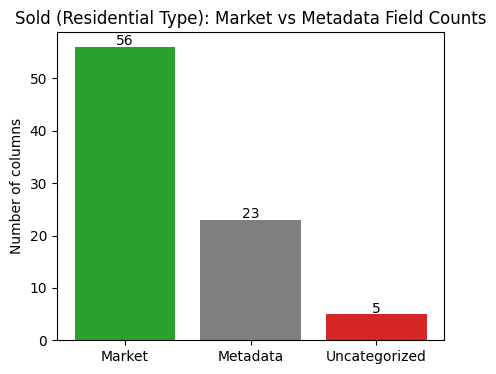

In [25]:
def classify_fields(df, label):
    print(f"\n--- [{label}] Field Classification ---")
    market, metadata, uncategorized = [], [], []
    for col in df.columns:
        if col in MARKET_FIELDS:
            market.append(col)
        elif col in METADATA_FIELDS:
            metadata.append(col)
        else:
            uncategorized.append(col)
 
    print(f"  Market analysis fields: {len(market)}")
    print(f"  Metadata fields: {len(metadata)}")
    if uncategorized:
        print(f"  Uncategorized (review and classify manually): {uncategorized}")
 
    fig, ax = plt.subplots(figsize=(5, 4))
    labels = ["Market", "Metadata", "Uncategorized"] if uncategorized else ["Market", "Metadata"]
    values = [len(market), len(metadata), len(uncategorized)] if uncategorized else [len(market), len(metadata)]
    ax.bar(labels, values, color=["#2ca02c", "#7f7f7f", "#d62728"][:len(labels)])
    ax.set_ylabel("Number of columns")
    ax.set_title(f"{label}: Market vs Metadata Field Counts")
    for i, v in enumerate(values):
        ax.text(i, v + 0.3, str(v), ha="center")
    save_and_show(fig, f"{label.lower()}_field_classification.png")
 
    return market, metadata, uncategorized
 
 
listing_market_cols, listing_meta_cols, listing_uncat_cols = classify_fields(Listing_Residential, "Listing (Residential Type)")
sold_market_cols, sold_meta_cols, sold_uncat_cols = classify_fields(Sold_Residential, "Sold (Residential Type)")

# Task 6: Review Numerical Variable Distributions


--- [Listing (Residential Type)] Numeric Field Summary ---
         ClosePrice     ListPrice    LivingArea  LotSizeAcres  BedroomsTotal  BathroomsTotalInteger   DaysOnMarket      YearBuilt
count  1.455200e+05  5.915680e+05  5.909660e+05  5.429950e+05  591406.000000          591511.000000  591568.000000  590552.000000
mean   1.209914e+06  1.318471e+06  1.980133e+03  6.142124e+01       3.226787               2.630220      18.650443    1979.687575
std    4.299804e+06  2.411076e+06  2.234907e+04  1.159967e+04       1.188341               3.135935      25.871264      27.026858
min    5.250000e+02  1.000000e+00  0.000000e+00  0.000000e+00       0.000000               0.000000     -58.000000    1776.000000
25%    6.000000e+05  5.808475e+05  1.248000e+03  1.200000e-01       2.000000               2.000000       5.000000    1961.000000
50%    8.585000e+05  8.489000e+05  1.672000e+03  1.700000e-01       3.000000               2.000000      11.000000    1980.000000
75%    1.352500e+06  1.385000e

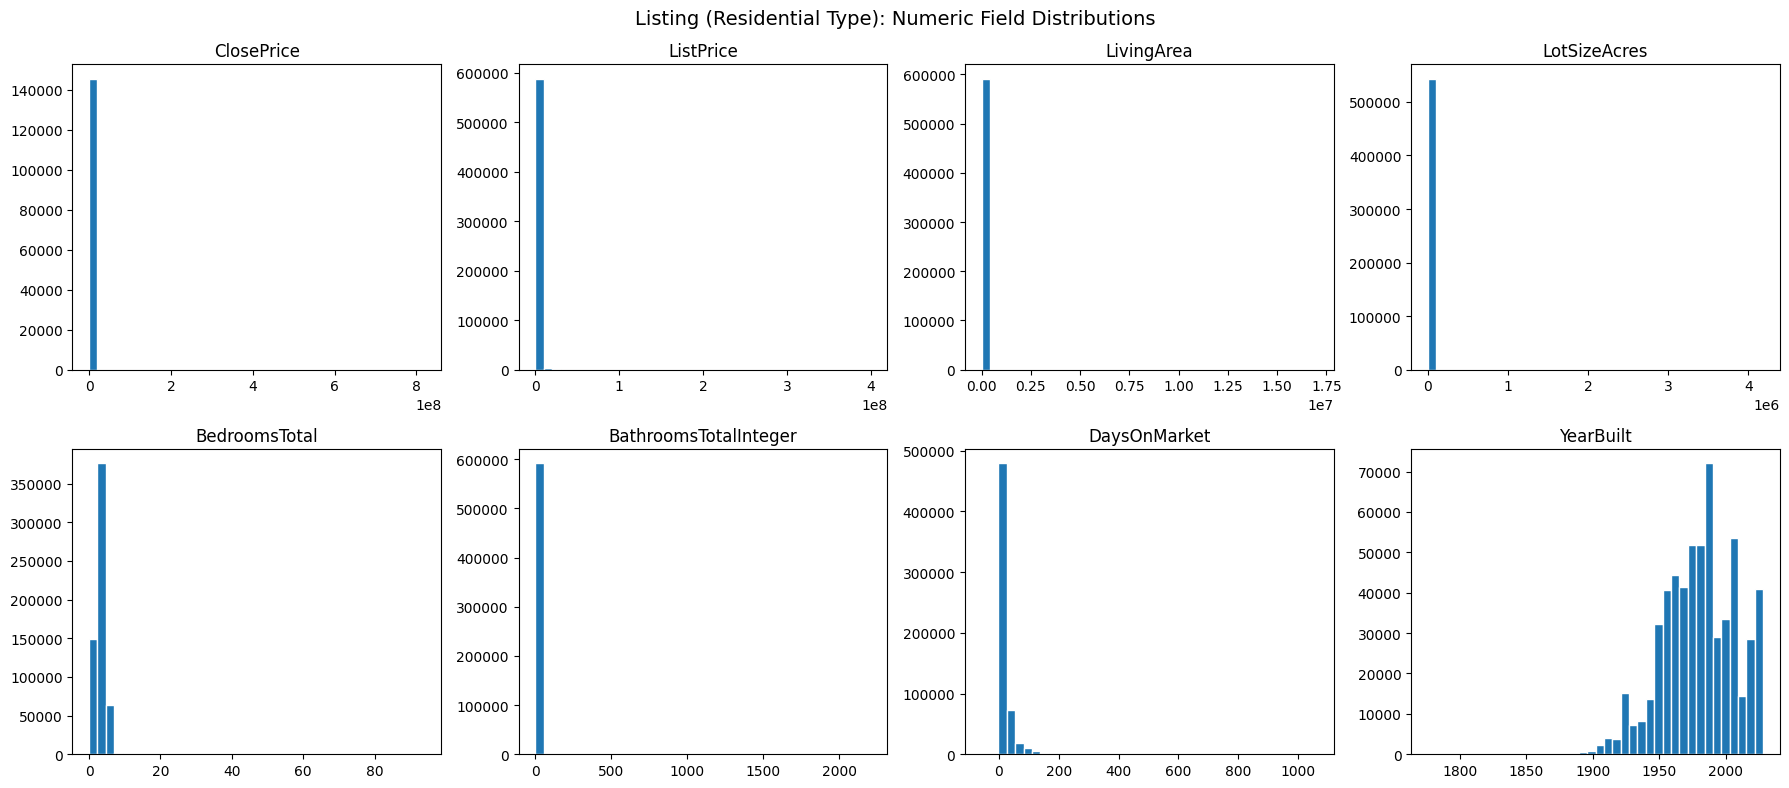


--- [Sold (Residential Type)] Numeric Field Summary ---
         ClosePrice     ListPrice    LivingArea  LotSizeAcres  BedroomsTotal  BathroomsTotalInteger   DaysOnMarket      YearBuilt
count  4.304450e+05  4.304470e+05  4.302020e+05  3.967930e+05  430435.000000          430377.000000  430447.000000  430065.000000
mean   1.193113e+06  1.141744e+06  1.904062e+03  6.400394e+01       3.203206               2.536664      37.334443    1978.601349
std    6.174107e+06  1.358097e+06  2.596796e+04  1.568745e+04       1.066833               1.132677      53.669772      26.292931
min    0.000000e+00  5.250000e+02  0.000000e+00  0.000000e+00       0.000000               0.000000    -288.000000    1776.000000
25%    5.750000e+05  5.780000e+05  1.248000e+03  1.200000e-01       3.000000               2.000000       8.000000    1960.000000
50%    8.250000e+05  8.190000e+05  1.644000e+03  1.665000e-01       3.000000               2.000000      18.000000    1979.000000
75%    1.300000e+06  1.295000e+06

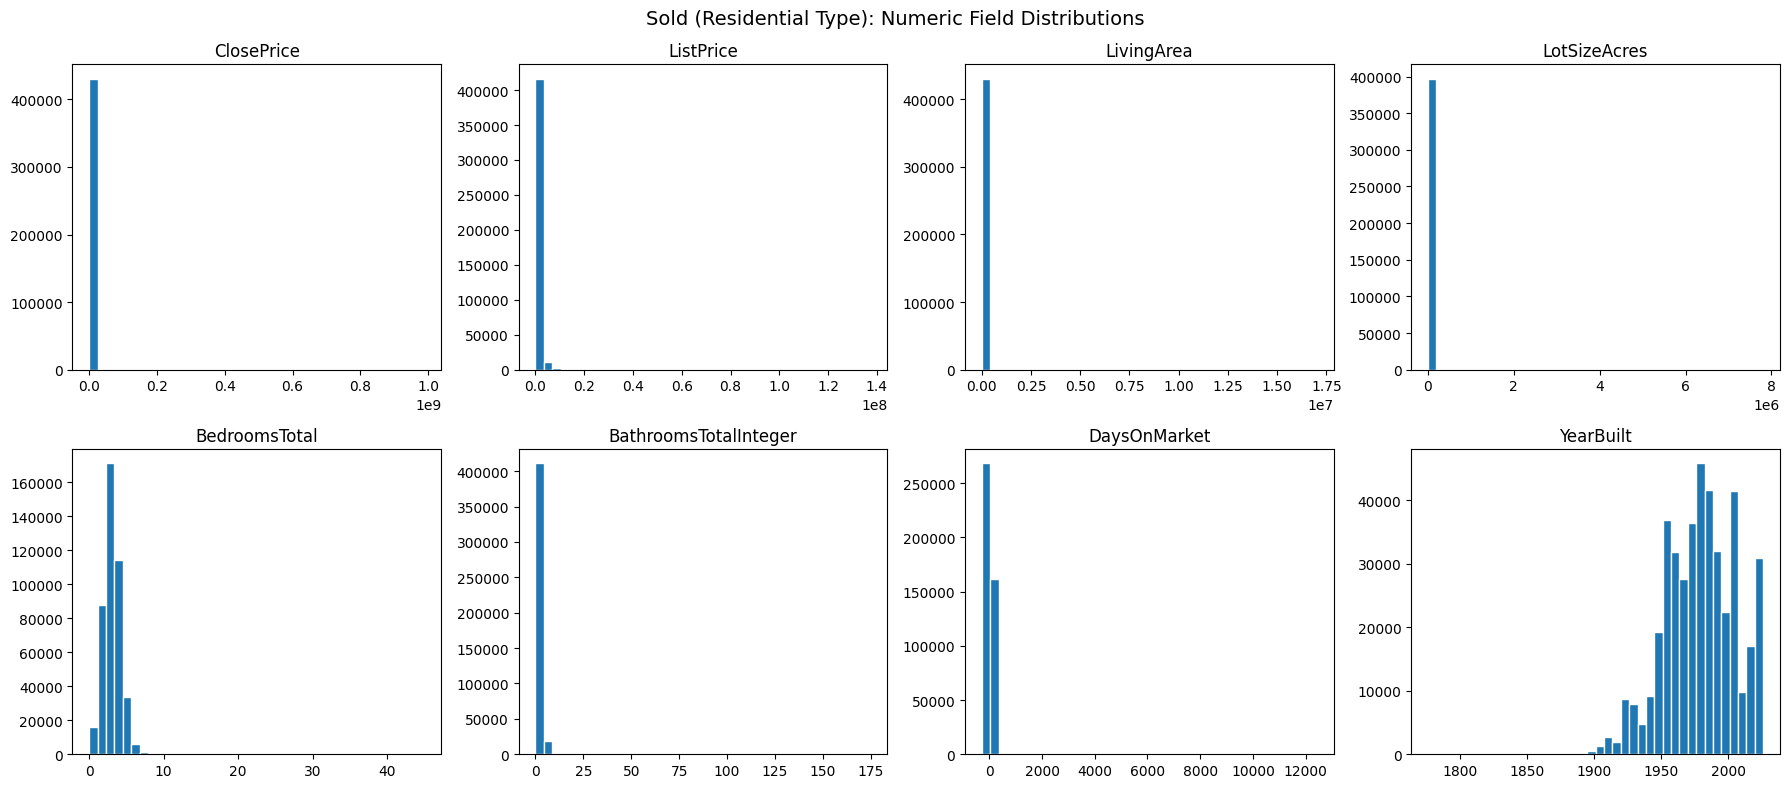

In [26]:
def numeric_distributions(df, label):
    print(f"\n--- [{label}] Numeric Field Summary ---")
    available = [c for c in NUMERIC_FIELDS if c in df.columns]
    print(df[available].describe().to_string())
 
    fig, axes = plt.subplots(2, 4, figsize=(18, 8))
    axes = axes.flatten()
    for i, col in enumerate(NUMERIC_FIELDS):
        ax = axes[i]
        if col not in df.columns:
            ax.set_visible(False)
            continue
        data = df[col].dropna()
        ax.hist(data, bins=40, color="#1f77b4", edgecolor="white")
        ax.set_title(col)
    fig.suptitle(f"{label}: Numeric Field Distributions", fontsize=14)
    fig.tight_layout()
    save_and_show(fig, f"{label.lower()}_numeric_distributions.png")
 
 
numeric_distributions(Listing_Residential, "Listing (Residential Type)")
numeric_distributions(Sold_Residential, "Sold (Residential Type)")

# Task 7: Answer EDA Questions


--- [Listing (Without Filter)] PropertyType Values ---
                      Count  Percent
PropertyType                        
Residential          591568    63.63
ResidentialLease     192309    20.68
Land                  60598     6.52
ResidentialIncome     34549     3.72
ManufacturedInPark    26626     2.86
CommercialSale        12714     1.37
CommercialLease        8366     0.90
BusinessOpportunity    2979     0.32

--- [Sold (Without Filter)] PropertyType Values ---
                      Count  Percent
PropertyType                        
Residential          430447    67.27
ResidentialLease     146567    22.90
Land                  20727     3.24
ManufacturedInPark    17325     2.71
ResidentialIncome     17133     2.68
CommercialSale         3981     0.62
CommercialLease        3320     0.52
BusinessOpportunity     420     0.07

--- [Listing (Without Filter)] Q1: Residential vs Other Share ---
  Residential: 591568 (63.6%)
  Other: 338141 (36.4%)
  Chart saved: D:\Meng\documen

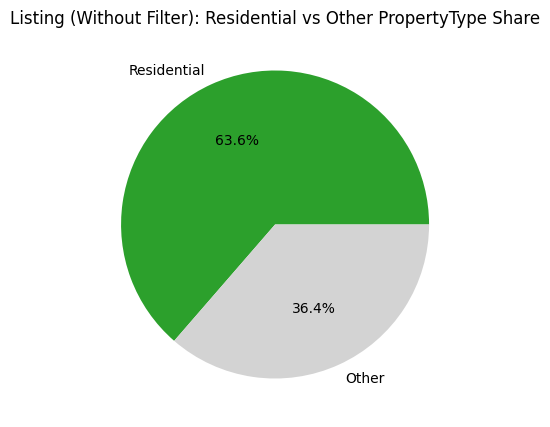


--- [Sold (Without FFilter)] Q1: Residential vs Other Share ---
  Residential: 430447 (67.3%)
  Other: 209473 (32.7%)
  Chart saved: D:\Meng\document\AU\Career\2026 Intern\IDX\2. Data Analyst summer 2026\csv\eda_charts\sold (without ffilter)_residential_share.png


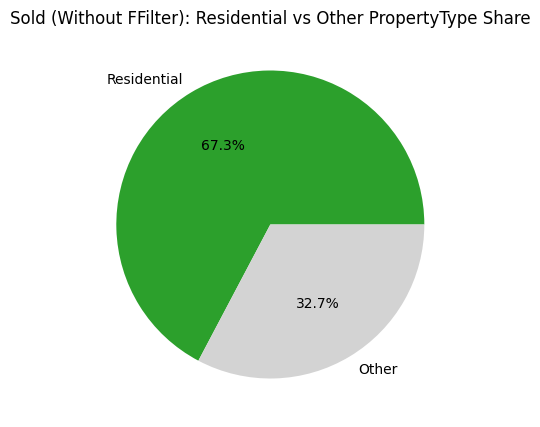

In [28]:
# Q1: Residential vs. other property type share
def residential_share(ptype_table, label):
    print(f"\n--- [{label}] Q1: Residential vs Other Share ---")
    total = ptype_table["Count"].sum()
    residential = ptype_table["Count"].get("Residential", 0)
    other = total - residential
    print(f"  Residential: {residential} ({residential / total * 100:.1f}%)")
    print(f"  Other: {other} ({other / total * 100:.1f}%)")
 
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.pie([residential, other], labels=["Residential", "Other"], autopct="%1.1f%%",
           colors=["#2ca02c", "#d3d3d3"])
    ax.set_title(f"{label}: Residential vs Other PropertyType Share")
    save_and_show(fig, f"{label.lower()}_residential_share.png")
 
listing_origin_ptype = review_property_types(Listing_Origin, "Listing (Without Filter)")
sold_origin_ptype = review_property_types(Sold_Origin, "Sold (Without Filter)")

residential_share(listing_origin_ptype, "Listing (Without Filter)")
residential_share(sold_origin_ptype, "Sold (Without FFilter)")

In [30]:
# Q2: Median and average close price
def close_price_stats(df, label):
    print(f"\n--- [{label}] Q2: Close Price Stats ---")
    prices = df["ClosePrice"].dropna()
    print(f"  n={len(prices)}, Median=${prices.median():,.0f}, Mean=${prices.mean():,.0f}")
 
 
close_price_stats(Sold_Residential, "Sold (Residential Type)")
close_price_stats(Listing_Residential[Listing_Residential["MlsStatus"] == "Closed"], "Listing (Residential Type via Closed subset)")


--- [Sold (Residential Type)] Q2: Close Price Stats ---
  n=430445, Median=$825,000, Mean=$1,193,113

--- [Listing (Residential Type via Closed subset)] Q2: Close Price Stats ---
  n=145515, Median=$858,500, Mean=$1,209,914



--- [Sold (Residential Type)] Q3: Days on Market Distribution ---
count    430447.000000
mean         37.334443
std          53.669772
min        -288.000000
25%           8.000000
50%          18.000000
75%          48.000000
max       12430.000000
  Negative DaysOnMarket rows (data quality flag): 49
  Chart saved: D:\Meng\document\AU\Career\2026 Intern\IDX\2. Data Analyst summer 2026\csv\eda_charts\sold (residential type)_dom_distribution.png


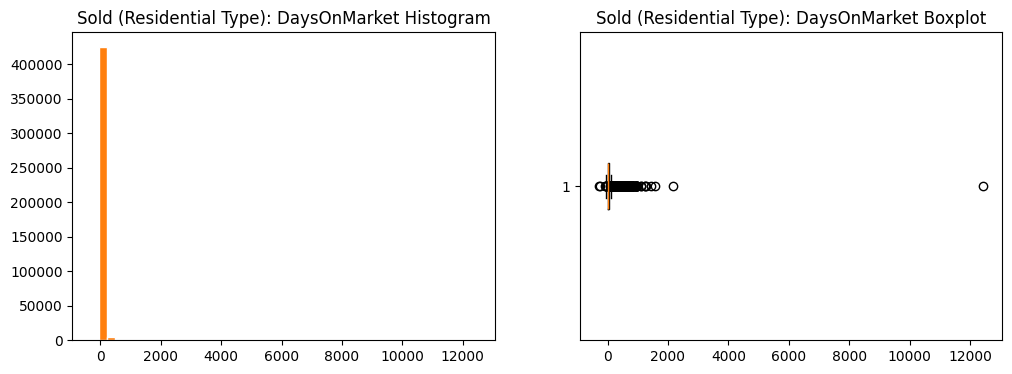

In [31]:
# Q3: Days on Market distribution
def dom_distribution(df, label):
    print(f"\n--- [{label}] Q3: Days on Market Distribution ---")
    dom = df["DaysOnMarket"].dropna()
    negative = (dom < 0).sum()
    print(dom.describe().to_string())
    print(f"  Negative DaysOnMarket rows (data quality flag): {negative}")
 
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(dom, bins=50, color="#ff7f0e", edgecolor="white")
    axes[0].set_title(f"{label}: DaysOnMarket Histogram")
    axes[1].boxplot(dom, vert=False)
    axes[1].set_title(f"{label}: DaysOnMarket Boxplot")
    save_and_show(fig, f"{label.lower()}_dom_distribution.png")
 
 
dom_distribution(Sold_Residential, "Sold (Residential Type)")


--- [Sold (Residential Type)] Q4: Sold Above vs Below List Price ---
  n=430445
  Above list: 172617 (40.1%)
  Below list: 183097 (42.5%)
  At list: 74731 (17.4%)
  Chart saved: D:\Meng\document\AU\Career\2026 Intern\IDX\2. Data Analyst summer 2026\csv\eda_charts\sold (residential type)_above_below_list.png


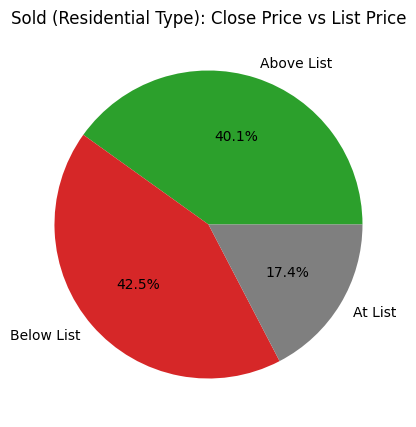

In [32]:
# Q4: % homes sold above vs below list price
def above_below_list(df, label):
    print(f"\n--- [{label}] Q4: Sold Above vs Below List Price ---")
    valid = df.dropna(subset=["ClosePrice", "ListPrice"])
    above = (valid["ClosePrice"] > valid["ListPrice"]).sum()
    below = (valid["ClosePrice"] < valid["ListPrice"]).sum()
    equal = (valid["ClosePrice"] == valid["ListPrice"]).sum()
    n = len(valid)
    print(f"  n={n}")
    print(f"  Above list: {above} ({above / n * 100:.1f}%)")
    print(f"  Below list: {below} ({below / n * 100:.1f}%)")
    print(f"  At list: {equal} ({equal / n * 100:.1f}%)")
 
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.pie([above, below, equal], labels=["Above List", "Below List", "At List"],
           autopct="%1.1f%%", colors=["#2ca02c", "#d62728", "#7f7f7f"])
    ax.set_title(f"{label}: Close Price vs List Price")
    save_and_show(fig, f"{label.lower()}_above_below_list.png")
 
 
above_below_list(Sold_Residential, "Sold (Residential Type)")

In [33]:
# Q5: Date consistency issues (e.g. close date before listing date)
def date_consistency_check(df, label):
    print(f"\n--- [{label}] Q5: Date Consistency Check ---")
    d = df.copy()
    d["_close"] = pd.to_datetime(d.get("CloseDate"), errors="coerce")
    d["_list"] = pd.to_datetime(d.get("ListingContractDate"), errors="coerce")
    both_present = d["_close"].notna() & d["_list"].notna()
    bad = d[both_present & (d["_close"] < d["_list"])]
    print(f"  Rows with both dates present: {both_present.sum()}")
    print(f"  Rows where CloseDate < ListingContractDate: {len(bad)} "
          f"({len(bad) / max(both_present.sum(), 1) * 100:.2f}%)")
    if "DaysOnMarket" in df.columns:
        neg_dom = (df["DaysOnMarket"] < 0).sum()
        print(f"  Rows with negative DaysOnMarket: {neg_dom}")
    if len(bad) > 0:
        cols_to_show = [c for c in ["ListingId", "ListingContractDate", "CloseDate"] if c in bad.columns]
        print("  Sample flagged rows:")
        print(bad[cols_to_show].head(5).to_string(index=False))
 
 
date_consistency_check(Listing_Residential, "Listing (Residential Type)")
date_consistency_check(Sold_Residential, "Sold (Residential Type)")


--- [Listing (Residential Type)] Q5: Date Consistency Check ---
  Rows with both dates present: 168464
  Rows where CloseDate < ListingContractDate: 79 (0.05%)
  Rows with negative DaysOnMarket: 30
  Sample flagged rows:
  ListingId ListingContractDate  CloseDate
240002340SD          2024-01-31 2024-01-30
240002006SD          2024-01-26 2024-01-25
240000171SD          2024-01-02 2024-01-01
240006096SD          2024-03-21 2024-03-20
  224001285          2024-04-08 2024-03-29

--- [Sold (Residential Type)] Q5: Date Consistency Check ---
  Rows with both dates present: 430446
  Rows where CloseDate < ListingContractDate: 65 (0.02%)
  Rows with negative DaysOnMarket: 49
  Sample flagged rows:
  ListingId ListingContractDate  CloseDate
240002340SD          2024-01-31 2024-01-30
240002006SD          2024-01-26 2024-01-25
240000171SD          2024-01-02 2024-01-01
  224001285          2024-04-08 2024-03-29
240006096SD          2024-03-21 2024-03-20



--- [Sold (Residential Type] Q6: Top 15 Counties by Median ClosePrice ---
CountyOrParish
Del Norte          2485000.0
Other County       2462500.0
San Mateo          1700000.0
Santa Clara        1600000.0
San Francisco      1199950.0
Santa Cruz         1199444.0
Orange             1180000.0
Marin              1172500.0
Alameda            1140000.0
Alpine             1100000.0
Mono                915000.0
Monterey            910000.0
Los Angeles         901000.0
San Diego           899000.0
San Luis Obispo     870000.0
  Chart saved: D:\Meng\document\AU\Career\2026 Intern\IDX\2. Data Analyst summer 2026\csv\eda_charts\sold (residential type_top_counties_price.png


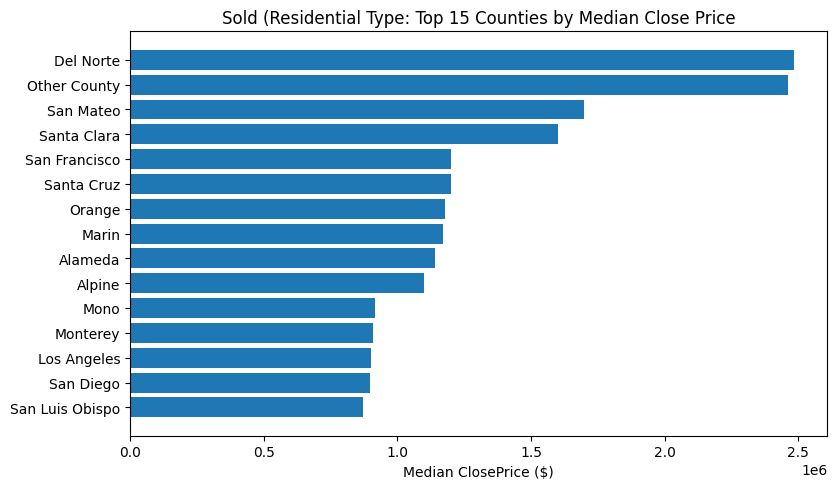


EDA complete. All charts saved to: D:\Meng\document\AU\Career\2026 Intern\IDX\2. Data Analyst summer 2026\csv\eda_charts


In [34]:
# Q6: Counties with the highest median prices
def top_counties_by_price(df, label, top_n=15):
    print(f"\n--- [{label}] Q6: Top {top_n} Counties by Median ClosePrice ---")
    valid = df.dropna(subset=["ClosePrice", "CountyOrParish"])
    county_median = valid.groupby("CountyOrParish")["ClosePrice"].median().sort_values(ascending=False)
    top = county_median.head(top_n)
    print(top.to_string())
 
    fig, ax = plt.subplots(figsize=(9, max(4, len(top) * 0.35)))
    ax.barh(top.index[::-1], top.values[::-1], color="#1f77b4")
    ax.set_xlabel("Median ClosePrice ($)")
    ax.set_title(f"{label}: Top {top_n} Counties by Median Close Price")
    save_and_show(fig, f"{label.lower()}_top_counties_price.png")
 
 
top_counties_by_price(Sold_Residential, "Sold (Residential Type")
 
print("\nEDA complete. All charts saved to:", CHART_DIR)